In [1]:
import pandas as pd
import numpy as np
import os
import sklearn

----------------

#### Importando a base de dados

In [2]:
dataset = pd.read_csv(r"../data/processed/Base NPS Tratada.csv")

In [3]:
dataset.head()

,Unnamed: 0,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,...,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,categoria_nps
0,0,1,63,Nordeste,14,50001,139.73,4,39.35,4,...,2,55.53,3,0,4,6.9,0,3,6.5,Detrator
1,1,2,20,Sul,1,50002,458.95,2,9.51,10,...,4,28.23,3,0,10,2.4,0,3,0.0,Detrator
2,2,3,46,Nordeste,111,50003,507.06,5,42.82,6,...,1,40.99,1,4,5,4.8,0,7,1.5,Detrator
3,3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,...,2,35.24,3,1,11,5.9,0,4,0.3,Detrator
4,4,5,56,Norte,50,50005,253.06,1,29.37,11,...,1,39.32,1,1,0,6.1,0,3,7.9,Detrator


####
------------------------------

#### Configurações

In [4]:
%matplotlib inline

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

####
--------------

#### Conhecendo os dados

In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 2500 non-null   int64  
 1   customer_id                2500 non-null   int64  
 2   customer_age               2500 non-null   int64  
 3   customer_region            2500 non-null   str    
 4   customer_tenure_months     2500 non-null   int64  
 5   order_id                   2500 non-null   int64  
 6   order_value                2500 non-null   float64
 7   items_quantity             2500 non-null   int64  
 8   discount_value             2500 non-null   float64
 9   payment_installments       2500 non-null   int64  
 10  delivery_time_days         2500 non-null   int64  
 11  delivery_delay_days        2500 non-null   int64  
 12  freight_value              2500 non-null   float64
 13  delivery_attempts          2500 non-null   int64  
 14  cus

In [6]:
# Aplicando tipo de str na coluna customer_id
dataset['customer_id'] = dataset['customer_id'].astype('str')

# Aplicando tipo de str na coluna order_id
dataset['order_id'] = dataset['order_id'].astype('str')

####
-----------------


#### Histograma

array([[<Axes: title={'center': 'Unnamed: 0'}>,
        <Axes: title={'center': 'customer_age'}>,
        <Axes: title={'center': 'customer_tenure_months'}>,
        <Axes: title={'center': 'order_value'}>],
       [<Axes: title={'center': 'items_quantity'}>,
        <Axes: title={'center': 'discount_value'}>,
        <Axes: title={'center': 'payment_installments'}>,
        <Axes: title={'center': 'delivery_time_days'}>],
       [<Axes: title={'center': 'delivery_delay_days'}>,
        <Axes: title={'center': 'freight_value'}>,
        <Axes: title={'center': 'delivery_attempts'}>,
        <Axes: title={'center': 'customer_service_contacts'}>],
       [<Axes: title={'center': 'resolution_time_days'}>,
        <Axes: title={'center': 'nps_score'}>,
        <Axes: title={'center': 'repeat_purchase_30d'}>,
        <Axes: title={'center': 'complaints_count'}>],
       [<Axes: title={'center': 'csat_internal_score'}>, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

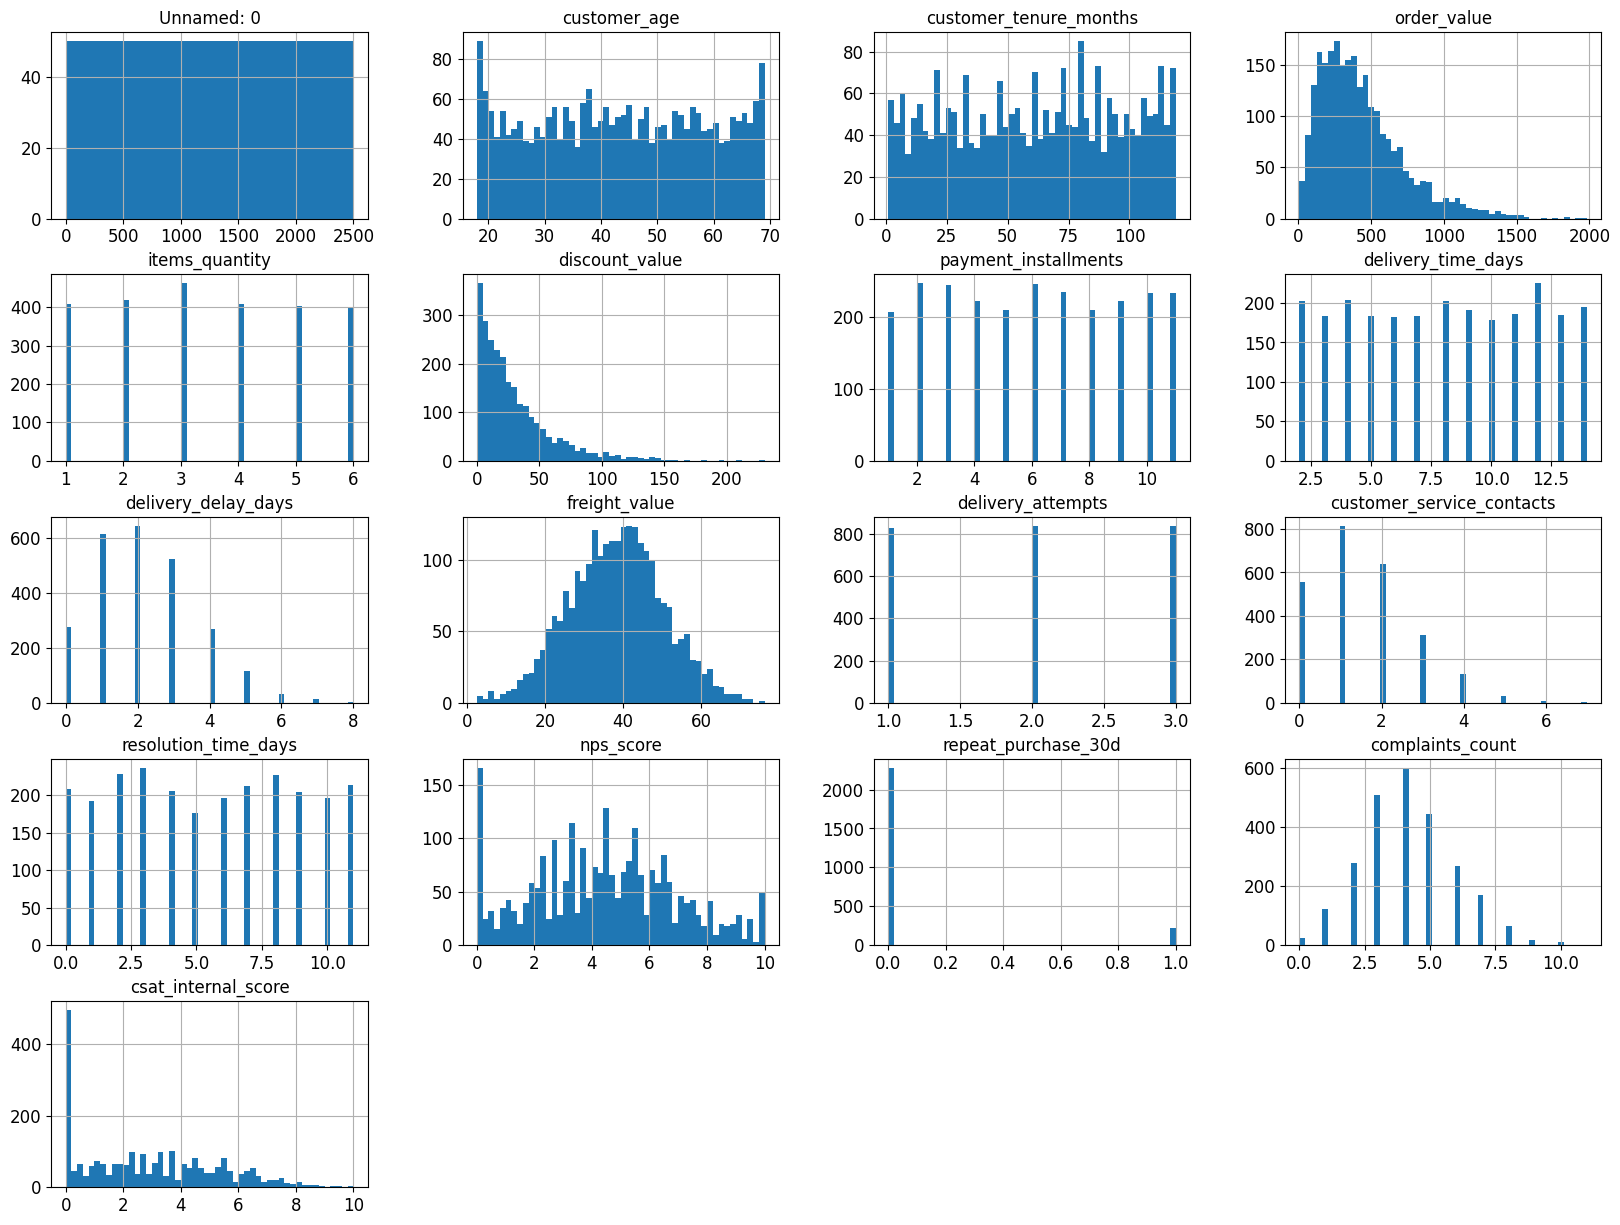

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
dataset.hist(bins=50, figsize=(20,15))

####
-----------------

#### Separando as bases em treino e teste

In [8]:
#Criando a base de treino e de teste usando train_test_split

from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(dataset, test_size = 0.2, random_state = 7)

In [9]:
#Verificando o tamanho da base de teste e de treino
print(len(df_train), "treinamento +", len(df_test), "teste")

2000 treinamento + 500 teste


####
-------------

#### Realizando amostragem estratificada

In [10]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state = 50)

for train_index, test_index in split.split(dataset, dataset['categoria_nps']):
    strat_train_set = dataset.loc[train_index]
    strat_test_set = dataset.loc[test_index]

In [11]:
# Analisando as proporções - Base de Teste
strat_test_set['categoria_nps'].value_counts()/len(strat_test_set)

categoria_nps
Detrator    0.844
Neutro      0.112
Promotor    0.044
Name: count, dtype: float64

In [12]:
# Analisando as proporções - Base de Treino
strat_train_set['categoria_nps'].value_counts()/len(strat_train_set)

categoria_nps
Detrator    0.8435
Neutro      0.1125
Promotor    0.0440
Name: count, dtype: float64

In [13]:
# Analisando as proporções - Base completa
dataset['categoria_nps'].value_counts()/len(dataset)

categoria_nps
Detrator    0.8436
Neutro      0.1124
Promotor    0.0440
Name: count, dtype: float64